# Flashzoi/Borzoi

In [1]:
%load_ext autoreload
%autoreload 2

import os
# only load this one time per session
if 'NOTEBOOK_INITIALIZED' not in globals():
    os.chdir(os.path.dirname(os.path.abspath('.')))
    NOTEBOOK_INITIALIZED = True

import pandas as pd
import polars as pl
import numpy as np
import torch
import genvarloader as gvl
import pooch
from tempfile import TemporaryDirectory
from pathlib import Path

import src.utils as utils
from torch.amp import autocast
import src.genvarloader as GVL
import src.flashzoi as fz
import src.clinvar as cv

# Set seed
np.random.seed(42)
torch.manual_seed(42)

In [2]:
device = "cuda:2"
model = fz.load_model()
model.to(device) 
model.eval() 
print()

Check the max batch size for the model before running out of GPU memory.

In [15]:
trks_dict = fz.test_batch_sizes(batch_sizes=range(5,100), 
                             L=2**18,
                             model=model,  
                             device=device)

batch size: 5
torch.Size([5, 7611, 6144])
batch size: 6
torch.Size([6, 7611, 6144])
batch size: 7


/home/schilder/.conda/envs/flashzoi/lib/python3.12/site-packages/borzoi_pytorch/pytorch_borzoi_model.py:282: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):


torch.Size([7, 7611, 6144])
batch size: 8
torch.Size([8, 7611, 6144])
batch size: 9
torch.Size([9, 7611, 6144])
batch size: 10
torch.Size([10, 7611, 6144])
batch size: 11
torch.Size([11, 7611, 6144])
batch size: 12
torch.Size([12, 7611, 6144])
batch size: 13
torch.Size([13, 7611, 6144])
batch size: 14
torch.Size([14, 7611, 6144])
batch size: 15
torch.Size([15, 7611, 6144])
batch size: 16
torch.Size([16, 7611, 6144])
batch size: 17
torch.Size([17, 7611, 6144])
batch size: 18
torch.Size([18, 7611, 6144])
batch size: 19
torch.Size([19, 7611, 6144])
batch size: 20
torch.Size([20, 7611, 6144])
batch size: 21
torch.Size([21, 7611, 6144])
batch size: 22
torch.Size([22, 7611, 6144])
batch size: 23
torch.Size([23, 7611, 6144])
batch size: 24
torch.Size([24, 7611, 6144])
batch size: 25
torch.Size([25, 7611, 6144])
batch size: 26
torch.Size([26, 7611, 6144])
batch size: 27
torch.Size([27, 7611, 6144])
batch size: 28
torch.Size([28, 7611, 6144])
batch size: 29
torch.Size([29, 7611, 6144])
batch si

## Run flashzoi

In [ ]:
seq_wt = utils.random_seqs(N=2, L=2**18, as_str=True)
seq_mut = [utils.get_mutated_sequence(seq) for seq in seq_wt]

trks_wt = fz.score_all_tracks(seq_wt, model=model, device=device, run_squeeze=True)
trks_mut = fz.score_all_tracks(seq_mut, model=model, device=device, run_squeeze=True)
delta = trks_mut - trks_wt

delta_metrics = fz.compute_vep_metrics(trks_wt=trks_wt, 
                                        trks_mut=trks_mut)
delta_metrics

Mutating 1.0% of sequence
Mutating 1.0% of sequence


/home/schilder/.conda/envs/flashzoi/lib/python3.12/site-packages/borzoi_pytorch/pytorch_borzoi_model.py:282: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):


{'delta': tensor([[[ 2.6003e-03,  3.8828e-04, -7.3426e-04,  ..., -4.0313e-05,
           -2.7401e-04, -6.6642e-04],
          [ 1.4121e-03, -1.8975e-03, -6.9909e-04,  ..., -1.5022e-04,
           -8.1576e-04, -2.7495e-03],
          [ 3.0480e-04, -8.4068e-04, -2.2624e-04,  ...,  3.2303e-06,
           -1.0101e-04,  6.9519e-05],
          ...,
          [-3.2773e-04, -9.5869e-04, -7.6745e-04,  ..., -3.8686e-04,
           -3.9630e-04, -4.9247e-04],
          [-4.1664e-04, -1.2750e-03, -9.8793e-04,  ..., -3.7454e-04,
           -4.8162e-04, -6.1368e-04],
          [-4.8993e-04, -1.4047e-03, -1.0654e-03,  ..., -1.8950e-04,
           -4.3440e-04, -5.3121e-04]],
 
         [[ 1.0288e-03,  9.4325e-04,  5.6169e-04,  ...,  2.2266e-03,
            1.8515e-03,  1.8823e-03],
          [ 2.5937e-03,  6.9124e-04,  1.4575e-03,  ...,  1.1718e-02,
            5.7982e-03,  1.6139e-03],
          [ 3.9448e-04,  3.8688e-04,  2.1941e-04,  ...,  9.1021e-04,
            4.9153e-04,  3.0663e-04],
          

## Run PCA on tracks delta

Here we input the delta array after taking the absolute values (since we don't care about directionality, just the amount of change in predictions).

In [39]:
import src.dimreduction as dr

pca_result =  dr.pca_sklearn(delta.abs().cpu())
{k:v.shape for k,v in pca_result.items() if k!="model"}

{'eigenvalues': (100,),
 'eigenvectors': (100, 6144),
 'projections': (7611, 100),
 'explained_variance_ratio': (100,)}

Import metadata for Flashzoi tracks.

In [26]:
# Check that they have the same number of rows
# (assuming that the rows are the same order)
targets = fz.load_targets(species=["human"])
print(targets["source"].value_counts())

source
encode      5855
fantom      1276
catlas       222
geo          169
recount3      89
Name: count, dtype: int64


Merge metadata with PCA projections.

In [27]:
X = pca_result["projections"]
# Convert PCA projections to DataFrame
pca_df = pd.DataFrame(
    X,
    columns=[f"PC{i+1}" for i in range(X.shape[1])]
)
assert targets.shape[0] == X.shape[0]
pca_df = pd.concat([targets.reset_index(), pca_df], axis=1)

### Get the samples that are driving the delta

We want to now which tissues/cell types are most affected by the mutation(s). We can run a PC on the delta of the two sets of tracks to find this out.

In [28]:
def get_top_loadings(pca_df,
                     groupby_col,
                     top_n = 5, 
                     exp=2,
                     max_pcs = 2):
    if groupby_col not in pca_df.columns:
        raise ValueError(f"Column '{groupby_col}' not found in DataFrame. Available columns: {pca_df.columns.tolist()}")
    top_res = {}
    for i in range(max_pcs):
        pc = f"PC{i+1}"
        top_res[pc] = pca_df.groupby(groupby_col)[pc].apply(lambda x:  (x**exp).mean()).sort_values(ascending=False).head(top_n)
        print(f"\n{pc} ({(pca_result["explained_variance_ratio"][i]*100).round(2)}% variance explained)")
        print(top_res[pc])

#### By assays

In [29]:
top_assays = get_top_loadings(pca_df, groupby_col="assay")


PC1 (84.58% variance explained)
assay
CHIP     4807.558205
CAGE      834.162828
RNA       795.586539
DNASE     683.157377
ATAC      516.130770
Name: PC1, dtype: float64

PC2 (3.69% variance explained)
assay
CHIP     226.428565
CAGE      18.625987
RNA       17.286147
DNASE     11.418100
ATAC      10.470451
Name: PC2, dtype: float64


#### By tissues

In [30]:
top_tissues = get_top_loadings(pca_df, groupby_col="tissue")


PC1 (84.58% variance explained)
tissue
H3K9me3:CD4-positive, alpha-beta T cell male adult (37 years)    851394.526574
H3K9me3:B cell male adult (37 years)                             655707.453302
H3K9me3:AG04450                                                  561885.636539
H3K9me3:CD14-positive monocyte male adult (21 year)              442165.927299
H3K9me3:stomach female embryo (96 days)                          277045.048671
Name: PC1, dtype: float64

PC2 (3.69% variance explained)
tissue
H3K9me3:CD4-positive, alpha-beta T cell male adult (37 years)                                                   22537.019603
H3K9me3:AG04450                                                                                                 17130.725972
H3K9me3:B cell male adult (37 years)                                                                            16107.174228
EZH2:GM23338 male adult (53 years) originated from GM23248                                                      14261.879262


### Get track sample metadata

{work in progress}

In [31]:
# import glob
# pd.set_option('display.max_columns', None)

# # Find all JSON files in the BioSamples directory
# json_files = glob.glob(os.path.expanduser("~/projects/data/BioSamples/*.json"))

# # Read and merge all JSON files into a single DataFrame
# biosamples_dfs = []
# for f in json_files:
#     query = os.path.basename(f).split(".")[0]
#     print(os.path.basename(f))
#     bs = pd.read_json(f) 
#     # Expand the nested characteristics dictionary into separate columns
#     bs = pd.concat([
#         bs.drop('characteristics', axis=1),
#         pd.json_normalize(bs['characteristics'].apply(lambda x: {k: v[0]['text'] if isinstance(v, list) and len(v) > 0 else None for k, v in x.items()}))
#     ], axis=1) 

#     print(bs.shape)
#     # bs = bs.loc[bs["name"].str.startswith("ENCODE")]
#     bs.insert(0,"query", query)
#     bs.insert(0,"id", bs["name"].str.split(" ").str[-1])

#     cols = ["sample type","cell type","tissue", "cell line"]
#     cols = [c for c in cols if c in bs.columns]
#     bs.loc[:,'sample'] = pd.NA
#     bs.loc[:,'sample'] = bs['sample'].fillna(bs[cols[1:]].bfill(axis=1).iloc[:, 0])
    
#     print({c:bs[c].notna().sum() for c in cols+["sample"]})
    
#     bs.fillna({"sample": "other"}, inplace=True)
#     extra_cols = ["id","ENCODE accession","name","sample"]
#     extra_cols = [c for c in extra_cols if c in bs.columns]
#     bs = bs.loc[:,extra_cols+cols]

#     biosamples_dfs.append(bs)

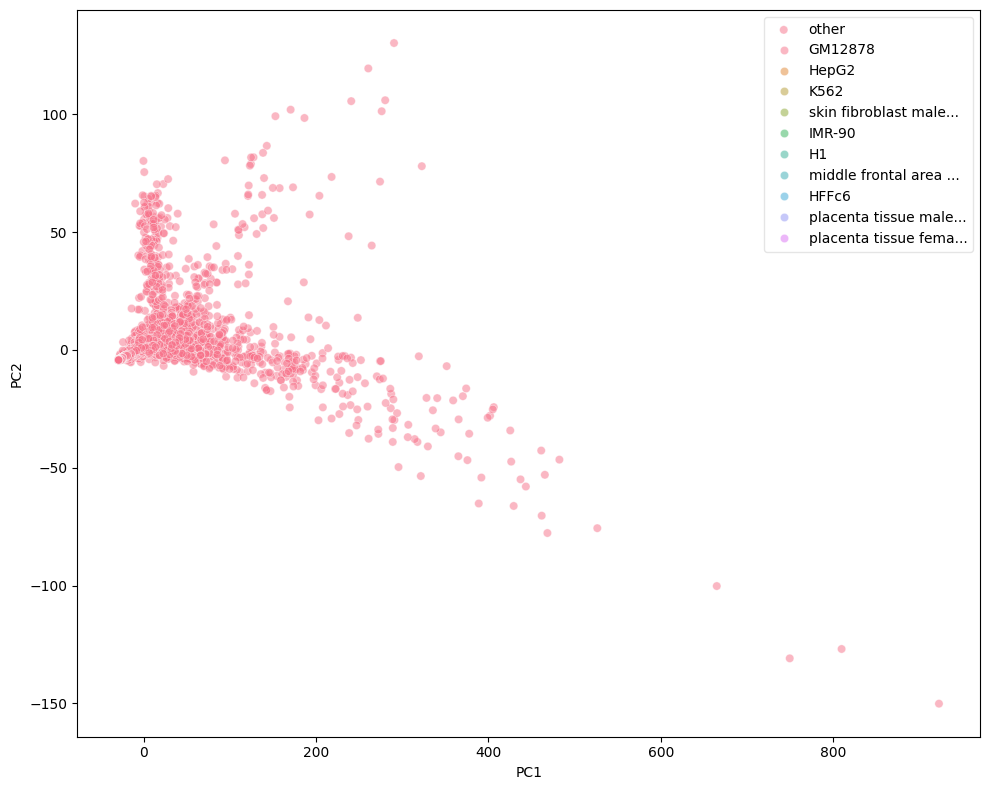

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt


trunc = 20
plt.figure(figsize=(10, 8))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="top_tissue", alpha=0.5)
legend = plt.legend(loc='upper right', 
                   labels=[label[:trunc] + '...' if len(label) > trunc else label 
                          for label in plt.gca().get_legend_handles_labels()[1]])
# Make legend background semi-transparent
legend.get_frame().set_alpha(0.5)
plt.tight_layout()

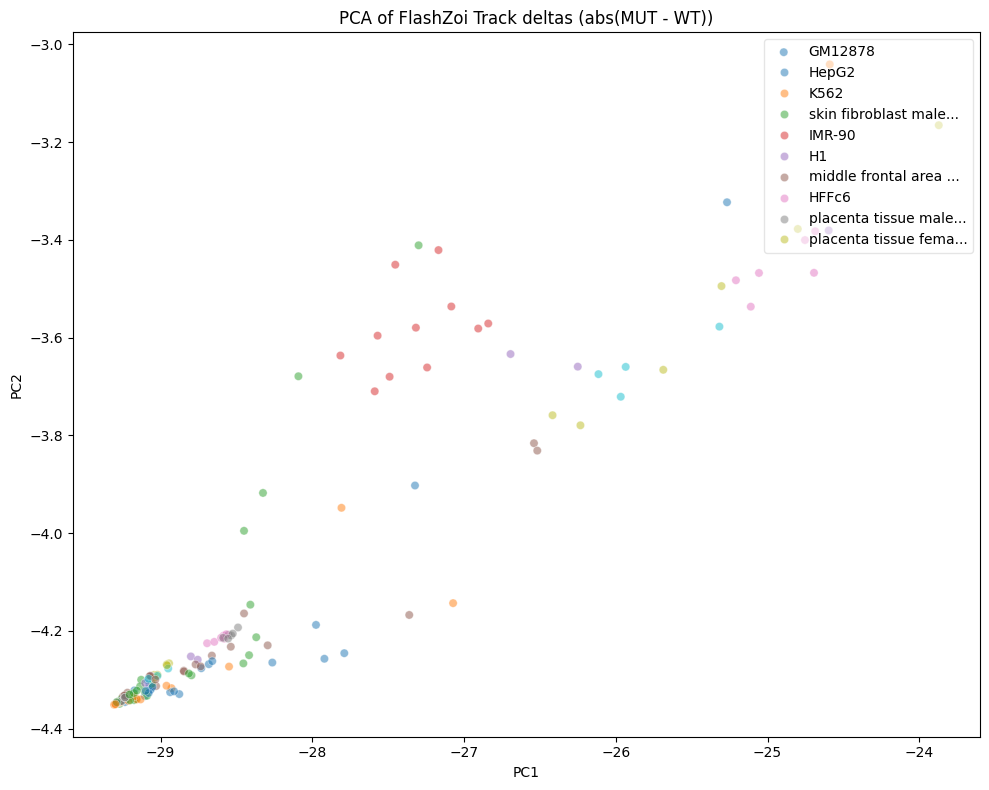

In [33]:
plt.figure(figsize=(10, 8))
# Plot "other" points first with small size and low alpha
# sns.scatterplot(data=pca_df.loc[pca_df["top_tissue"]=="other"], x="PC1", y="PC2", hue="top_tissue", alpha=0.1, size=0.1, legend=False)
# Plot labeled points on top with normal size
sns.scatterplot(data=pca_df.loc[pca_df["top_tissue"]!="other"], x="PC1", y="PC2", hue="top_tissue", alpha=0.5)
plt.title('PCA of FlashZoi Track deltas (abs(MUT - WT))')
legend = plt.legend(loc='upper right', 
                   labels=[label[:trunc] + '...' if len(label) > trunc else label 
                          for label in plt.gca().get_legend_handles_labels()[1]])
# Make legend background semi-transparent
legend.get_frame().set_alpha(0.5)
plt.tight_layout()

## Compute cosine similarity

### Directly on logits

Compute cosin similarity along the tracks or sequence axes.

In [34]:
import src.vep_metrics as vm

css = {}
for dim in [0,1]:
    print(f"\ndim{dim}")
    res = vm.cosine_sim(out1,
                        out2,
                        css_agg_func=None, 
                        # dim=0 returns compute cos sim along the sequence axis
                        # dim=1 returns compute cos sim along the 100PC axis
                        dim=dim)
    css[f"dim{dim}"] = res
    print(res.shape)
    # print(res)
    print("CSS mean:",res.mean())
    print("CSS variance:",res.var())


dim0
Computing cosine similarity without aggregating logits
Returning cosine similarity without aggregating cosine similarity vector
torch.Size([7611, 6144])
CSS mean: tensor(1., device='cuda:2')
CSS variance: tensor(0., device='cuda:2')

dim1
Computing cosine similarity without aggregating logits
Returning cosine similarity without aggregating cosine similarity vector
torch.Size([1, 6144])
CSS mean: tensor(0.9579, device='cuda:2')
CSS variance: tensor(0.0016, device='cuda:2')


### On PCA eigenvectors


Reduce the track predictions from both sequences in one PCA. Then extract the eigenvectors (100 PCs x sequence length) for each sequence and compare them with cosine similarity.

Note: Here we don't want to take the absolute of the track values, because we need to retain info about directionality for comparing the two PCA embeddings afterwards.

In [40]:
pca_ax0 =  dr.pca_sklearn(torch.concat([out1,out2], axis=1).cpu())

In [41]:
css_pca_ax0 = {}
for dim in [0,1]:
    print(f"\ndim{dim}")
    res = vm.cosine_sim(pca_ax0["eigenvectors"][:,1:out1.shape[1]],
                        pca_ax0["eigenvectors"][:,out1.shape[1]+1:],
                        css_agg_func=None, 
                        # dim=0 returns compute cos sim along the sequence axis
                        # dim=1 returns compute cos sim along the 100PC axis
                        dim=dim)
    css_pca_ax0[f"dim{dim}"] = res
    print(res.shape)
    # print(res)
    print("CSS mean:",res.mean())
    print("CSS variance:",res.var())


dim0
Computing cosine similarity without aggregating logits
Returning cosine similarity without aggregating cosine similarity vector
torch.Size([6143])
CSS mean: tensor(0.0028, dtype=torch.float64)
CSS variance: tensor(0.0105, dtype=torch.float64)

dim1
Computing cosine similarity without aggregating logits
Returning cosine similarity without aggregating cosine similarity vector
torch.Size([100])
CSS mean: tensor(-0.0008, dtype=torch.float64)
CSS variance: tensor(0.0095, dtype=torch.float64)


Compute cosin similarity along the sequence axis instead.

In [42]:
pca_ax1 = dr.pca_sklearn(torch.concat([out1,out2], axis=0).cpu())

In [43]:
css_pca_ax1 = {}
for dim in [0,1]:
    print(f"\ndim{dim}")
    res = vm.cosine_sim(pca_ax1["projections"][1:out1.shape[0],:],
                        pca_ax1["projections"][out1.shape[0]+1:,:],
                        css_agg_func=None, 
                        # dim=0 returns compute cos sim along the sequence axis
                        # dim=1 returns compute cos sim along the 100PC axis
                        dim=dim)
    css_pca_ax1[f"dim{dim}"] = res
    print(res.shape)
    # print(res)
    print("CSS mean:",res.mean())
    print("CSS variance:",res.var())


dim0
Computing cosine similarity without aggregating logits
Returning cosine similarity without aggregating cosine similarity vector
torch.Size([100])
CSS mean: tensor(-0.0052, dtype=torch.float64)
CSS variance: tensor(0.0975, dtype=torch.float64)

dim1
Computing cosine similarity without aggregating logits
Returning cosine similarity without aggregating cosine similarity vector
torch.Size([7610])
CSS mean: tensor(0.5351, dtype=torch.float64)
CSS variance: tensor(0.3527, dtype=torch.float64)


### Compare direct vs. PCA cos sim

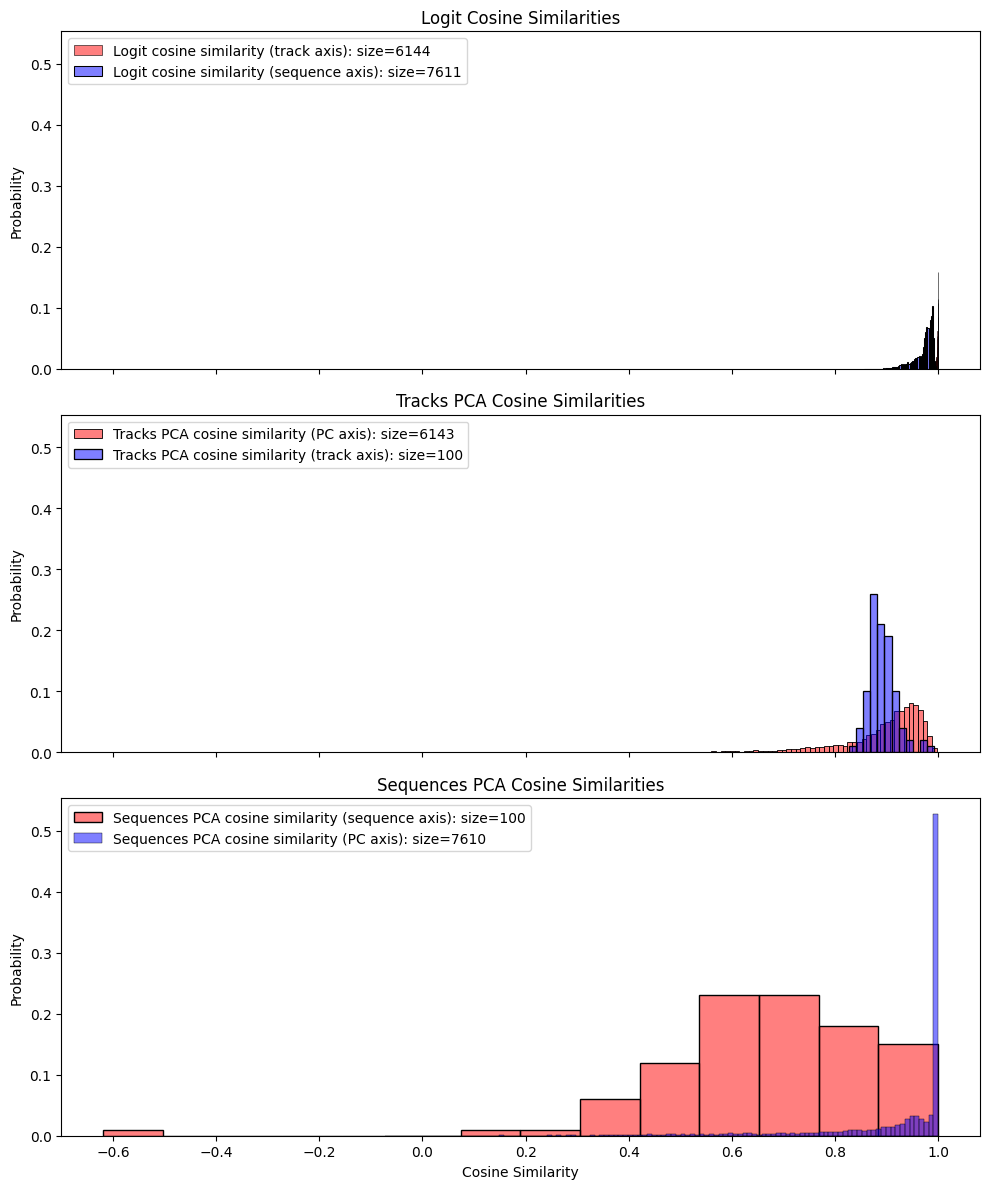

In [258]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 12), 
                               sharex=True, 
                               sharey=True)
colors=["red","blue"]
stat="probability"
bins="auto"

# Top subplot - Logit cosine similarities
colors=["red","blue"]
axis_names = ["track","sequence",]
for i, (dim, data) in enumerate(css.items()):
    sns.histplot(data=data.cpu(), stat=stat, alpha=0.5, bins=bins,
                 label=f"Logit cosine similarity ({axis_names[i]} axis): size={len(data)}", 
                 color=colors[i],
                 ax=ax1)
ax1.set_xlabel('Cosine Similarity')
ax1.set_title('Logit Cosine Similarities')
ax1.legend(loc='upper left')


# Middle subplot - track PCA cosine similarities
axis_names = ["PC","track"]
for i, (dim, data) in enumerate(css_pca_ax0.items()):
    sns.histplot(data=data.cpu(), stat=stat, alpha=0.5, bins=bins,
                 label=f"Tracks PCA cosine similarity ({axis_names[i]} axis): size={len(data)}", 
                 color=colors[i],
                 ax=ax2)
ax2.set_xlabel('Cosine Similarity')
ax2.set_title('Tracks PCA Cosine Similarities')
ax2.legend(loc='upper left')



# Botom subplot - sequence PCA cosine similarities
axis_names = ["sequence","PC"]
for i, (dim, data) in enumerate(css_pca_ax1.items()):
    sns.histplot(data=data.cpu(), stat=stat, alpha=0.5, bins=bins,
                 label=f"Sequences PCA cosine similarity ({axis_names[i]} axis): size={len(data)}", 
                 color=colors[i],
                 ax=ax3)
ax3.set_xlabel('Cosine Similarity')
ax3.set_title('Sequences PCA Cosine Similarities')
ax3.legend(loc='upper left')

# sns.histplot(data=css_pca.cpu(), stat=stat, alpha=0.5, label='PCA cosine similarity (track axis)', color='red', ax=ax2)
# sns.histplot(data=css_pca_ax1.cpu(), stat=stat, alpha=0.5, label='PCA cosine similarity (sequence axis)', color='blue', ax=ax2)
# ax2.set_xlabel('Cosine Similarity')
# ax2.set_title('PCA Cosine Similarities')
# ax2.legend(loc='upper left')

plt.tight_layout()
plt.show()

## Run flashzoi in batches of sequences

In [2]:
# GRCh38 chromosome 22 sequence
reference = pooch.retrieve(
    url="https://ftp.ensembl.org/pub/release-112/fasta/homo_sapiens/dna/Homo_sapiens.GRCh38.dna.chromosome.22.fa.gz",
    known_hash="sha256:974f97ac8ef7ffae971b63b47608feda327403be40c27e391ee4a1a78b800df5",
    progressbar=True,
)
if not Path(f"{reference[:-3]}.bgz").exists():
    !gzip -dc {reference} | bgzip > {reference[:-3]}.bgz
reference = reference[:-3] + ".bgz"

# PLINK 2 files
variants = pooch.retrieve(
    url="doi:10.5281/zenodo.13656224/1kGP.chr22.pgen",
    known_hash="md5:31aba970e35f816701b2b99118dfc2aa",
    progressbar=True,
    fname="1kGP.chr22.pgen",
)
pooch.retrieve(
    url="doi:10.5281/zenodo.13656224/1kGP.chr22.psam",
    known_hash="md5:eefa7aad5acffe62bf41df0a4600129c",
    progressbar=True,
    fname="1kGP.chr22.psam",
)
pooch.retrieve(
    url="doi:10.5281/zenodo.13656224/1kGP.chr22.pvar",
    known_hash="md5:5f922af91c1a2f6822e2f1bb4469d12b",
    progressbar=True,
    fname="1kGP.chr22.pvar",
)

# BED
bed_path = pooch.retrieve(
    url="doi:10.5281/zenodo.13656224/chr22_egenes.bed",
    known_hash="md5:ccb55548e4ddd416d50dbe6638459421",
    progressbar=True,
)


In [3]:
bed = cv.read_bed("data/UTR/clinvar_utr_snv.bed.gz") 
# bed = gvl.read_bedlike(bed_path)

print(bed.shape)
bed.head()

(13771, 25)


chrom,chromStart,chromEnd,name,score,REF,ALT,MC_id,MC_term,AF_ESP,AF_EXAC,AF_TGP,ALLELEID,CLNDISDB,CLNDN,CLNHGVS,CLNREVSTAT,CLNSIG,CLNVC,CLNVCSO,GENEINFO,CLNREVSTAT_score,CLNSIG_simple,CLNSIG_super_simple,GENE
str,i64,i64,str,f64,str,str,str,str,f64,f64,f64,i64,str,str,str,str,str,str,str,str,i64,str,str,str
"""1""",1013541,1013542,"""chr1:1013541-1013542_T_C""",2.0,"""T""","""C""","""SO:0001623""","""5_prime_UTR_variant""",0.88579,null,0.90315,1175251,"""MedGen:C3661900|MONDO:MONDO:00…","""not_provided|Mendelian_suscept…","""NC_000001.11:g.1013541T>C""","""criteria_provided,_multiple_su…","""Benign""","""single_nucleotide_variant""","""SO:0001483""","""ISG15:9636""",2,"""benign""","""benign""","""ISG15"""
"""1""",1055000,1055001,"""chr1:1055000-1055001_C_T""",2.0,"""C""","""T""","""SO:0001624""","""3_prime_UTR_variant""",0.34176,0.33342,0.34345,249353,"""MedGen:CN169374|MONDO:MONDO:00…","""not_specified|Congenital_myast…","""NC_000001.11:g.1055000C>T""","""criteria_provided,_multiple_su…","""Benign""","""single_nucleotide_variant""","""SO:0001483""","""AGRN:375790""",2,"""benign""","""benign""","""AGRN"""
"""1""",1055037,1055038,"""chr1:1055037-1055038_T_C""",2.0,"""T""","""C""","""SO:0001624""","""3_prime_UTR_variant""",null,null,0.38399,1282674,"""MedGen:C3661900""","""not_provided""","""NC_000001.11:g.1055037T>C""","""criteria_provided,_multiple_su…","""Benign""","""single_nucleotide_variant""","""SO:0001483""","""AGRN:375790""",2,"""benign""","""benign""","""AGRN"""
"""1""",1055137,1055138,"""chr1:1055137-1055138_C_T""",2.0,"""C""","""T""","""SO:0001624""","""3_prime_UTR_variant""",null,null,0.91793,1175253,"""MONDO:MONDO:0014052,MedGen:C38…","""Congenital_myasthenic_syndrome…","""NC_000001.11:g.1055137C>T""","""criteria_provided,_multiple_su…","""Benign""","""single_nucleotide_variant""","""SO:0001483""","""AGRN:375790""",2,"""benign""","""benign""","""AGRN"""
"""1""",1055153,1055154,"""chr1:1055153-1055154_G_A""",2.0,"""G""","""A""","""SO:0001624""","""3_prime_UTR_variant""",null,null,0.12181,1282812,"""MedGen:C3661900""","""not_provided""","""NC_000001.11:g.1055153G>A""","""criteria_provided,_multiple_su…","""Benign""","""single_nucleotide_variant""","""SO:0001483""","""AGRN:375790""",2,"""benign""","""benign""","""AGRN"""


In [4]:
ds_path = TemporaryDirectory(suffix=".gvl").name

bed_chrom = bed.filter(pl.col('chrom').str.replace("chr","")=='22')
force = False
if not os.path.exists(ds_path) or force:
    gvl.write(
        path=ds_path,
        bed=gvl.with_length(bed_chrom[:20], 2**18),  # change region length to 131,072 bp
        variants=variants,
        overwrite=True,
    )

2025-05-23 18:20:25.525 | INFO     | genvarloader._dataset._write:write:75 - Writing dataset to /tmp/tmpbj57mi4b.gvl
2025-05-23 18:20:25.531 | INFO     | genoray._pgen:_read_index:1078 - Loading genoray index.


2025-05-23 18:20:25.922 | INFO     | genvarloader._dataset._write:write:147 - Using 451 samples.
2025-05-23 18:20:25.922 | INFO     | genvarloader._dataset._write:write:153 - Writing genotypes.


  0%|          | 0/20 [00:00<?, ? region/s]

2025-05-23 18:20:27.255 | INFO     | genvarloader._dataset._write:write:177 - Finished writing.


In [71]:
ds = (
    gvl.Dataset.open(ds_path, reference=reference)
    .with_seqs("haplotypes") 
    .with_len(2**18)
)

ds_ref = (
    gvl.Dataset.open(ds_path, reference=reference)
    .with_seqs("reference") 
    .with_len(2**18)
)

2025-05-23 19:41:11.586 | INFO     | genvarloader._dataset._impl:open:192 - Loading reference genome into memory. This typically has a modest memory footprint (a few GB) and greatly improves performance.
2025-05-23 19:41:11.608 | INFO     | genvarloader._dataset._reconstruct:from_path:183 - Loading variant data.
2025-05-23 19:41:11.631 | INFO     | genvarloader._dataset._impl:open:278 - Opened dataset:
GVL store at /tmp/tmpbj57mi4b.gvl
Is subset: False
# of regions: 20
# of samples: 451
Output length: ragged
Jitter: 0 (max: 0)
Deterministic: True
Sequence type: reference [haplotypes] annotated variants
Active tracks: None
Tracks available: None

2025-05-23 19:41:11.634 | INFO     | genvarloader._dataset._impl:open:192 - Loading reference genome into memory. This typically has a modest memory footprint (a few GB) and greatly improves performance.
2025-05-23 19:41:11.655 | INFO     | genvarloader._dataset._reconstruct:from_path:183 - Loading variant data.
2025-05-23 19:41:11.673 | INFO  

In [72]:
# Convert BED to sites
sites = cv.bed_to_sites(bed) 

sites_chrom = sites.filter(pl.col("CHROM").str.replace("chr","")=="22")

# Import sites_ds
site_ds = gvl.DatasetWithSites(ds, sites_chrom) 
site_ds_ref = gvl.DatasetWithSites(ds_ref, sites_chrom)

site_ds

In [91]:
row_idx = 0
wt_haps, mut_haps, flags = site_ds[row_idx, :]
print(wt_haps.haps.shape)
# Import the sequences for the REF sample
## All samples are REF, just use the first one
wt_haps_ref, mut_haps_ref, flags_ref = site_ds_ref[row_idx, [0]] 
wt_haps_ref.haps = wt_haps_ref.haps[0]
mut_haps_ref.haps = mut_haps_ref.haps[0]
print(wt_haps_ref.shape)


(451, 2, 262144)
(1, 2, 262144)


In [108]:
seq_as_str = False
sample_names = ds.samples[:10]

# Import all the haplotypes for region/batch
wt_haps, mut_haps, flags = site_ds[row_idx, sample_names] 

## Get the wildtype (wt) haplotype sequences
seq_wt = GVL.haps_to_seqs(haps=wt_haps,  
                            as_str=seq_as_str)
print(seq_wt.shape)

## Get the mutated (mut) haplotype sequences
seq_mut = GVL.haps_to_seqs(haps=mut_haps,  
                            as_str=seq_as_str) 

(20, 262144)


In [102]:
wt_haps_ref, mut_haps_ref, flags_ref = site_ds_ref[row_idx, [0]] 
print(wt_haps_ref.shape)

(1, 1, 2, 262144)


In [103]:
## Get the wildtype (wt) sequence and add to haplotype sequences
seq_wt_ref = GVL.haps_to_seqs(haps=wt_haps_ref,  
                                as_str=seq_as_str)
seq_wt = np.concatenate([seq_wt,seq_wt_ref], axis=0)    

In [107]:
seq_mut_ref = GVL.haps_to_seqs(haps=mut_haps_ref,  
                                                   as_str=seq_as_str)

seq_mut_ref

array([[b'T', b'G', b'A', ..., b'A', b'G', b'A'],
       [b'T', b'G', b'A', ..., b'A', b'A', b'C']],
      shape=(2, 262144), dtype='|S1')

In [109]:
from tqdm import tqdm
import torch
import src.flashzoi as fz

row_idx = 0

batches = utils.split_batches(ds.samples)

device = "cuda:1"
model = fz.load_model(device=device, eval=True)

batched_results = []

# Import all the haplotypes for the region at once to reduce overhead
wt_haps, mut_haps, flags = site_ds[row_idx, :]

# Iterate over batches
for batch_idx, sample_idx in tqdm(enumerate(batches),
                                  total=len(batches),
                                  desc="Iterating over batches",
                                  leave=False):     
    # Extract sequences
    seqs_wt =GVL.haps_to_seqs(haps=wt_haps,  
                              sample_idx=sample_idx,
                              as_str=False)
    seqs_mut = GVL.haps_to_seqs(haps=mut_haps, 
                                 sample_idx=sample_idx,
                                 as_str=False)
    
    # print("seqs.shape", seqs.shape)
    
    # Score tracks
    trks_wt = fz.score_all_tracks(seqs_wt, model=model, device=device)
    trks_mut = fz.score_all_tracks(seqs_mut, model=model, device=device)
    # print("trks.shape", trks.shape)

    break

    # Store results
    batched_results.append(trks_wt.cpu().numpy())
    
    # Free memory
    del seqs_wt, seqs_mut, trks_wt, trks_mut
    torch.cuda.empty_cache()
    
    



IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

In [8]:
import src.flashzoi as fz

results = fz.compute_pca_metrics(trks_wt=trks_wt, 
                         trks_mut=trks_mut, 
                         verbose=True)

Computing PCA CSS:   0%|          | 0/24 [00:00<?, ?it/s]

Computing cosine similarity without aggregating logits
Returning cosine similarity without aggregating cosine similarity vector
Computing cosine similarity without aggregating logits
Returning cosine similarity without aggregating cosine similarity vector
Computing cosine similarity without aggregating logits
Returning cosine similarity without aggregating cosine similarity vector
Computing cosine similarity without aggregating logits
Returning cosine similarity without aggregating cosine similarity vector
Computing cosine similarity without aggregating logits
Returning cosine similarity without aggregating cosine similarity vector
Computing cosine similarity without aggregating logits
Returning cosine similarity without aggregating cosine similarity vector
Computing cosine similarity without aggregating logits
Returning cosine similarity without aggregating cosine similarity vector
Computing cosine similarity without aggregating logits
Returning cosine similarity without aggregating c

In [ ]:
results = fz.compute_delta_metrics(trks_wt=trks_wt, 
                         trks_mut=trks_mut, 
                         verbose=True)

results["delta_max_max"]

Computing delta metrics for batched results


tensor([0.0000, 0.0000, 2.1200, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        3.1762, 0.0000, 0.0000, 2.4953, 0.0000, 0.0000, 1.7168, 0.0000, 0.0000,
        2.2345, 0.0000, 0.0000, 2.5312, 0.0000, 0.0000])

In [15]:
batched_results[0]

array([[[1.29157249e-02, 1.24407355e-02, 7.79904053e-03, ...,
         2.52947980e-03, 2.47801596e-04, 3.09186202e-04],
        [1.83000788e-02, 2.02447549e-02, 1.83775984e-02, ...,
         3.29567888e-03, 2.63396010e-04, 9.71638437e-05],
        [4.14393283e-03, 3.07842833e-03, 1.89062883e-03, ...,
         1.22670596e-03, 8.16669126e-05, 1.13809911e-04],
        ...,
        [2.61140428e-02, 2.92773061e-02, 2.83640418e-02, ...,
         2.20266525e-02, 2.84001557e-03, 2.33986950e-03],
        [2.61221118e-02, 3.03044468e-02, 3.00493483e-02, ...,
         3.23124081e-02, 4.22869157e-03, 3.52489878e-03],
        [2.06219777e-02, 2.48288698e-02, 2.48155240e-02, ...,
         3.26260179e-02, 4.53649694e-03, 3.22863599e-03]],

       [[1.17804864e-02, 1.06059564e-02, 6.27674442e-03, ...,
         2.20231456e-03, 2.43274029e-04, 3.08217481e-04],
        [1.52342422e-02, 1.82722062e-02, 1.40109509e-02, ...,
         3.60349170e-03, 2.73639598e-04, 1.30558416e-04],
        [3.70043865e-03, 